In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data/clownmitmuetze_with_features_engineered.csv')

In [3]:
df.head()

,game_id,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval,mate,eval_volatility,pieces_remaining,...,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white
0,03jXYvoC,1,5,1800.03,0.00,1.000017,19.0,NaN,NaN,32,...,19.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0
1,03jXYvoC,2,5,1803.07,1.96,1.001706,14.0,NaN,NaN,32,...,14.0,1.0,0.000000,0.000000,0.000000,0.000000,0.025641,0.0,0.030810,0
2,03jXYvoC,3,5,1806.43,1.64,1.003572,9.0,NaN,4.082483,32,...,9.0,1.0,0.019473,0.000000,0.000000,0.000000,0.051282,0.0,0.037727,0
3,03jXYvoC,4,5,1809.55,1.88,1.005306,25.0,NaN,6.683313,32,...,25.0,1.0,0.031878,0.000000,0.000000,0.000000,0.076923,0.0,0.043072,0
4,03jXYvoC,5,5,1748.91,65.64,0.971617,-20.0,NaN,18.624953,32,...,-20.0,1.0,0.088838,0.028383,0.028383,0.002522,0.102564,0.0,0.447191,0


In [4]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'eval', 'mate', 'eval_volatility',
       'pieces_remaining', 'material_density', 'num_minor_pieces', 'num_rooks',
       'num_queens', 'num_pawns', 'complexity_material_score',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_opening', 'is_middlegame',
       'is_endgame', 'is_pawn_move', 'is_knight_move', 'is_bishop_move',
       'is_rook_move', 'is_queen_move', 'is_king_move',
       'avg_time_spent_per_move', 'time_spent_ratio', 'is_mate_threat',
       'is_checkmate', 'is_inaccuracy', 'is_mistake', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white'],
      dtype='str')

In [ ]:
# Drop unneeded columns
df = df.drop(['game_id', 'eval', 'mate'], axis = 1)

In [6]:
df.dtypes

move_number                     int64
increment_sec                   int64
time_left_sec                 float64
time_spent_sec                float64
time_left_ratio               float64
eval_volatility               float64
pieces_remaining                int64
material_density              float64
num_minor_pieces                int64
num_rooks                       int64
num_queens                      int64
num_pawns                       int64
complexity_material_score       int64
white_castled_king              int64
white_castled_queen             int64
black_castled_king              int64
black_castled_queen             int64
queen_present                   int64
is_opening                      int64
is_middlegame                   int64
is_endgame                      int64
is_pawn_move                    int64
is_knight_move                  int64
is_bishop_move                  int64
is_rook_move                    int64
is_queen_move                   int64
is_king_move

In [7]:
[col for col in df.columns if df[col].dtype == 'str']

[]

In [8]:
df.isnull().sum()

move_number                      0
increment_sec                    0
time_left_sec                    0
time_spent_sec                   0
time_left_ratio                  0
eval_volatility               4352
pieces_remaining                 0
material_density                 0
num_minor_pieces                 0
num_rooks                        0
num_queens                       0
num_pawns                        0
complexity_material_score        0
white_castled_king               0
white_castled_queen              0
black_castled_king               0
black_castled_queen              0
queen_present                    0
is_opening                       0
is_middlegame                    0
is_endgame                       0
is_pawn_move                     0
is_knight_move                   0
is_bishop_move                   0
is_rook_move                     0
is_queen_move                    0
is_king_move                     0
avg_time_spent_per_move          0
time_spent_ratio    

In [9]:
# Can drop the eval_volatility rows since NA for the first 2 moves and are negligible
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

move_number                   0
increment_sec                 0
time_left_sec                 0
time_spent_sec                0
time_left_ratio               0
eval_volatility               0
pieces_remaining              0
material_density              0
num_minor_pieces              0
num_rooks                     0
num_queens                    0
num_pawns                     0
complexity_material_score     0
white_castled_king            0
white_castled_queen           0
black_castled_king            0
black_castled_queen           0
queen_present                 0
is_opening                    0
is_middlegame                 0
is_endgame                    0
is_pawn_move                  0
is_knight_move                0
is_bishop_move                0
is_rook_move                  0
is_queen_move                 0
is_king_move                  0
avg_time_spent_per_move       0
time_spent_ratio              0
is_mate_threat                0
is_checkmate                  0
is_inacc

In [11]:
df.duplicated().sum()

np.int64(0)

No duplicated rows

In [13]:
df.nunique()

move_number                     104
increment_sec                    27
time_left_sec                 16529
time_spent_sec                 5086
time_left_ratio               39410
eval_volatility               16988
pieces_remaining                 31
material_density                 31
num_minor_pieces                  9
num_rooks                         6
num_queens                        4
num_pawns                        17
complexity_material_score        77
white_castled_king                2
white_castled_queen               2
black_castled_king                2
black_castled_queen               2
queen_present                     2
is_opening                        2
is_middlegame                     2
is_endgame                        2
is_pawn_move                      2
is_knight_move                    2
is_bishop_move                    2
is_rook_move                      2
is_queen_move                     2
is_king_move                      2
avg_time_spent_per_move     

In [14]:
from IPython.display import display
pd.options.display.max_columns = None

In [15]:
df.describe()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,avg_time_spent_per_move,time_spent_ratio,is_mate_threat,is_checkmate,is_inaccuracy,is_mistake,is_blunder,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white
count,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000,71274.000000
mean,22.353733,6.897270,430.279695,16.043117,0.788321,150.318760,22.678803,0.708713,4.618009,2.962272,1.042484,12.609745,50.657491,0.551786,0.115708,0.538373,0.090861,0.649143,0.210554,0.370009,0.419438,0.276061,0.172167,0.166947,0.147768,0.117238,0.119819,15.579143,1.018410,0.025465,0.002960,0.037040,0.013020,0.014325,106.960977,0.649455,0.217250,0.339363,0.164823,0.095064,0.514173,0.293027,0.822221,0.454724
std,14.742827,8.769567,564.808333,29.793635,1.467657,784.808311,7.205306,0.225166,2.507279,1.438371,0.862979,2.713244,21.302496,0.497314,0.319877,0.498529,0.287413,0.477242,0.407705,0.482810,0.493470,0.447051,0.377528,0.372931,0.354872,0.321706,0.324752,10.097100,1.339305,0.157534,0.054329,0.188862,0.113362,0.118828,2362.644106,0.273109,0.259644,0.328092,0.170054,0.179689,0.272359,0.367994,0.390490,0.497949
min,3.000000,0.000000,0.290000,0.000000,0.000000,0.000000,2.000000,0.062500,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.666000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9696.500000,0.025641,0.000000,0.000000,0.000000,0.000000,0.018868,0.000000,0.000848,0.000000
25%,11.000000,3.000000,169.230000,2.840000,0.377790,10.077478,17.000000,0.531250,3.000000,2.000000,0.000000,11.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.902143,0.225262,0.000000,0.000000,0.000000,0.000000,0.000000,-102.000000,0.410256,0.048068,0.010996,0.009604,0.000137,0.277778,0.000000,0.530095,0.000000
50%,20.000000,5.000000,317.230000,7.160000,0.750072,24.055491,24.000000,0.750000,5.000000,4.000000,1.000000,13.000000,54.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.842381,0.554852,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.692308,0.114741,0.249928,0.126038,0.019254,0.515152,0.000000,0.930920,0.000000
75%,31.000000,9.000000,537.150000,17.560000,0.989004,56.394937,29.000000,0.906250,7.000000,4.000000,2.000000,15.000000,70.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.928649,1.265987,0.000000,0.000000,0.000000,0.000000,0.000000,112.000000,0.897436,0.268996,0.622210,0.257531,0.094544,0.750000,0.666667,1.076169,1.000000
max,106.000000,180.000000,14593.870000,1215.400000,66.086000,12547.890052,32.000000,1.000000,8.000000,5.000000,3.000000,16.000000,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00

Noted nothing unusual

In [17]:
binary_columns = [
    col for col in df.columns
    if df[col].nunique() == 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
binary_columns

['white_castled_king',
 'white_castled_queen',
 'black_castled_king',
 'black_castled_queen',
 'queen_present',
 'is_opening',
 'is_middlegame',
 'is_endgame',
 'is_pawn_move',
 'is_knight_move',
 'is_bishop_move',
 'is_rook_move',
 'is_queen_move',
 'is_king_move',
 'is_mate_threat',
 'is_checkmate',
 'color_white']

In [18]:
def plot_binary_feature_analysis(df, binary_features, target=''):
    n_features = len(binary_features)
    n_cols = 3
    n_rows = 20
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 25))
    axes = axes.flatten()
    
    for idx, feature in enumerate(binary_features):
        ax = axes[idx]
        
        # Calculate counts and percentages
        crosstab = pd.crosstab(df[feature], df[target])
        crosstab_pct = pd.crosstab(df[feature], df[target], normalize='index') * 100
        
        # Plot grouped bars
        x = np.arange(2)
        width = 0.35
        
        ax.bar(x - width/2, crosstab[0], width, label= f'No {target}', color='skyblue')
        ax.bar(x + width/2, crosstab[1], width, label= f'{target}', color='coral')
        
        # Add percentage labels
        for i, (no_pct, yes_pct) in enumerate(zip(crosstab_pct[0], crosstab_pct[1])):
            ax.text(i - width/2, crosstab.iloc[i, 0], f'{no_pct:.1f}%', 
                    ha='center', va='bottom', fontsize=9)
            ax.text(i + width/2, crosstab.iloc[i, 1], f'{yes_pct:.1f}%', 
                    ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel(f'{feature}')
        ax.set_ylabel('Count')
        ax.set_title(f'{feature} vs {target}')
        ax.set_xticks(x)
        ax.set_xticklabels(['No', 'Yes'])
        ax.legend()
    
    # Hide empty subplots if there are any
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

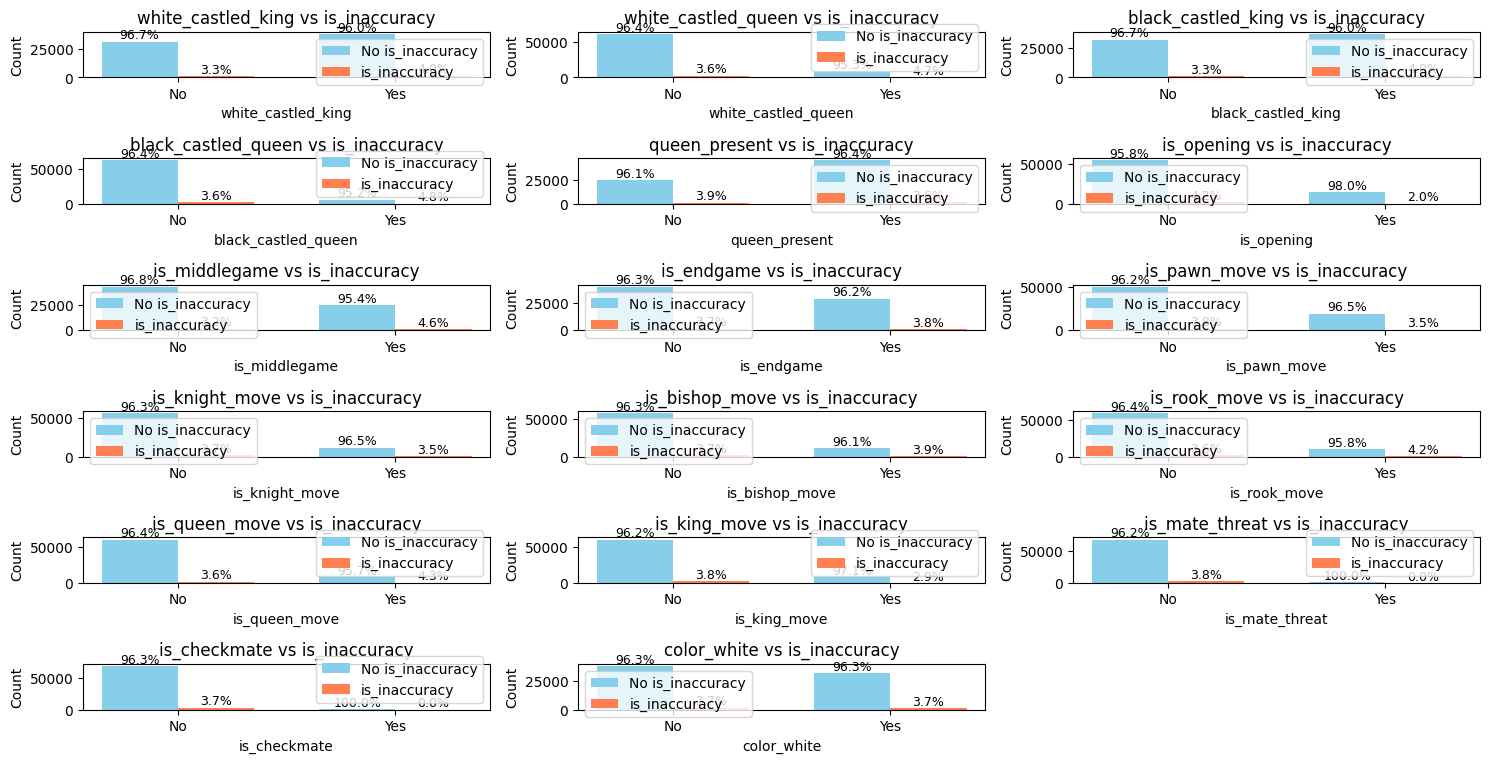

In [19]:
plot_binary_feature_analysis(df, binary_columns, target='is_inaccuracy')

Observations
* For inaccuracies, it looks like:
* King Moves - about 3% of king moves is inaccuracy
* Queen moves - about 4.3% of queen moves is inaccuracy
* rook moves - 4.2% for rook
* bishop move - 4% of move
* knight moves - 3.5% of move
* pawn moves - 3.5% for pawn

* No clear correlation based off piece type
* It is interesting to see the more powerful pieces (queen and rook) have higher inaccuracy rates Compared to king and minor pieces which are less powerful

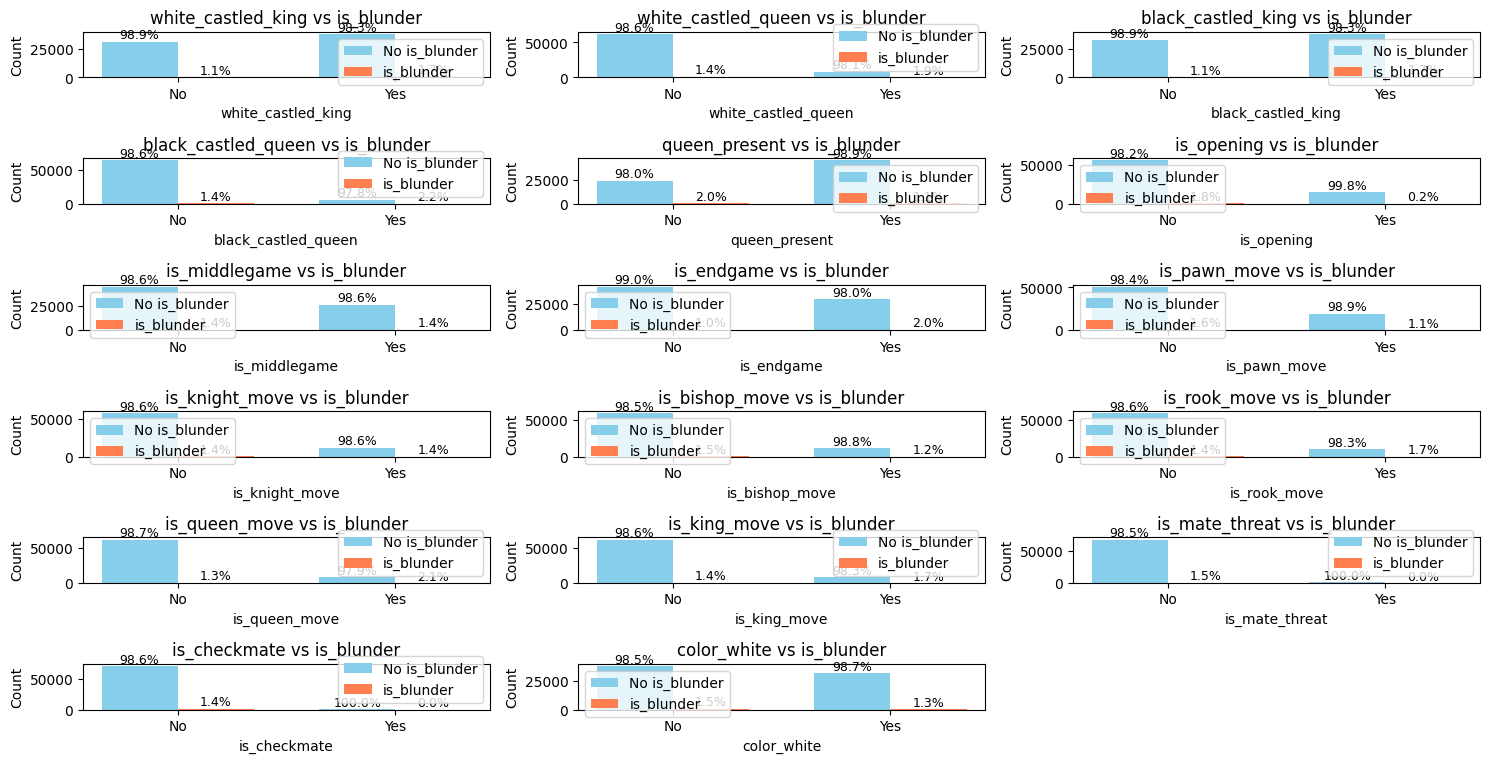

In [21]:
plot_binary_feature_analysis(df, binary_columns, target='is_blunder')

Observations
* For blunders, it looks like: 
* King Moves - about 1.7% of king moves 
* Queen moves - about 2.1% of queen moves 
* rook moves - 1.7% for rook
* bishop move - 1.2% of move
* knight moves - 1.4% of move
* pawn moves - 1.1% for pawn

* all blunder rates are lower than inaccruacy rates
* It is interesting to see the more powerful pieces (queen and rook) have higher inaccuracy rates Compared to king and minor pieces which are less powerful

In [23]:
is_inaccuracy_percentages = df.groupby('is_inaccuracy')[binary_columns].agg('mean') * 100
is_inaccuracy_percentages

,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,is_mate_threat,is_checkmate,color_white
is_inaccuracy,,,,,,,,,,,,,,,,,
0,54.982953,11.452050,53.645424,8.979515,64.973628,21.428155,36.656759,41.915086,27.655389,17.246554,16.666667,14.693883,11.653117,12.084390,2.644462,0.307428,45.483288
1,60.265152,14.659091,58.825758,11.856061,63.371212,11.363636,45.946970,42.689394,26.325758,16.439394,17.424242,16.931818,13.560606,9.318182,0.000000,0.000000,45.189394


In [24]:
is_blunder_percentages = df.groupby('is_blunder')[binary_columns].agg('mean') * 100
is_blunder_percentages

,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,is_mate_threat,is_checkmate,color_white
is_blunder,,,,,,,,,,,,,,,,,
0,55.031102,11.516946,53.700198,9.018832,65.113234,21.315816,36.996285,41.687899,27.707002,17.223464,16.730958,14.743854,11.642207,11.952514,2.58352,0.300343,45.515494
1,65.328110,15.279138,63.271303,13.712047,51.224290,3.134182,37.316357,59.549461,20.666014,16.748286,14.201763,17.042116,17.335945,14.005877,0.00000,0.000000,42.507346


In [25]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure']

In [26]:
def plot_numeric_features_histogram(df, numeric_features, target='', bins=10):
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = 10
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
    axes = axes.flatten()
    
    for idx, feature in enumerate(numeric_features):
        ax = axes[idx]
        
        # Separate data by diabetes status
        no_diabetes = df[df[target] == 0][feature]
        yes_diabetes = df[df[target] == 1][feature]
        
        # Plot histograms
        ax.hist(no_diabetes, bins=bins, color='skyblue', 
                label= f'No {target}', density=True, histtype='step', linewidth=2.5)
        ax.hist(yes_diabetes, bins=bins, color='coral', 
                label= f'{target}', density=True, histtype='step', linewidth=2.5)
        
        # Styling
        ax.set_xlabel(feature, fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Distribution of {feature} by {target}', fontsize=12, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

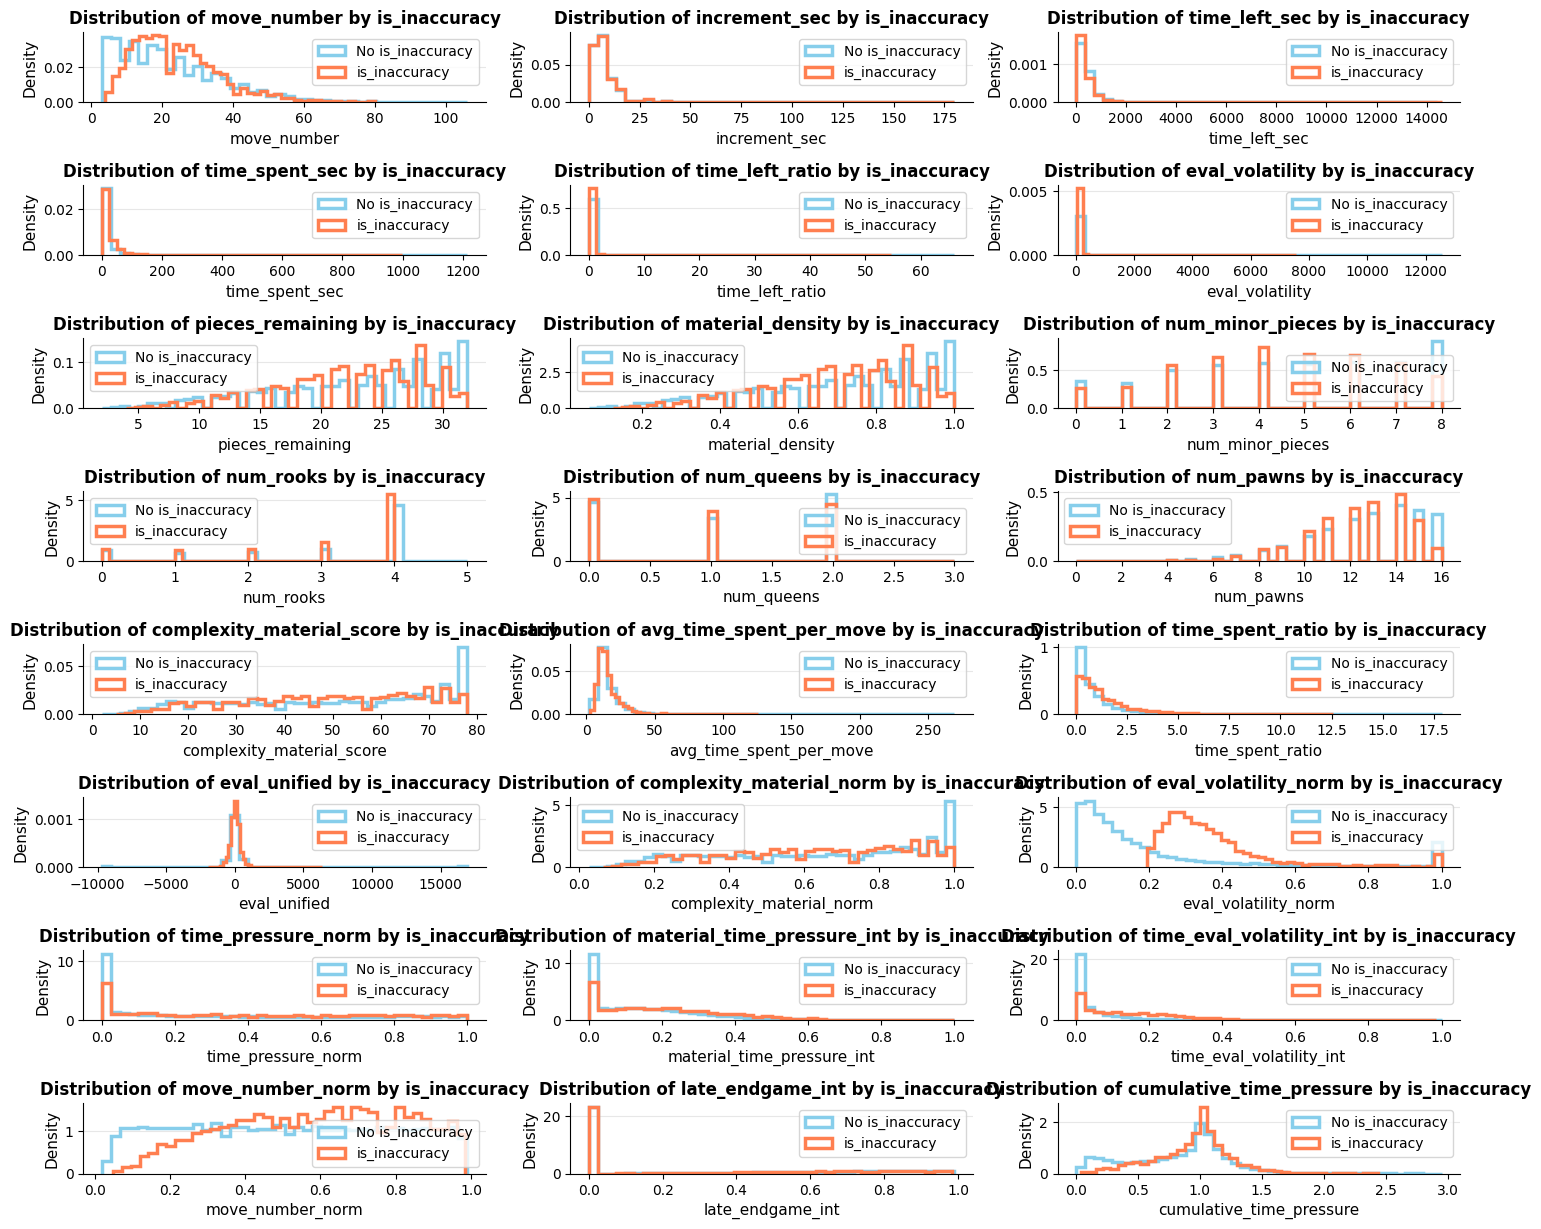

In [27]:
plot_numeric_features_histogram(df, numeric_columns, target='is_inaccuracy', bins=40)

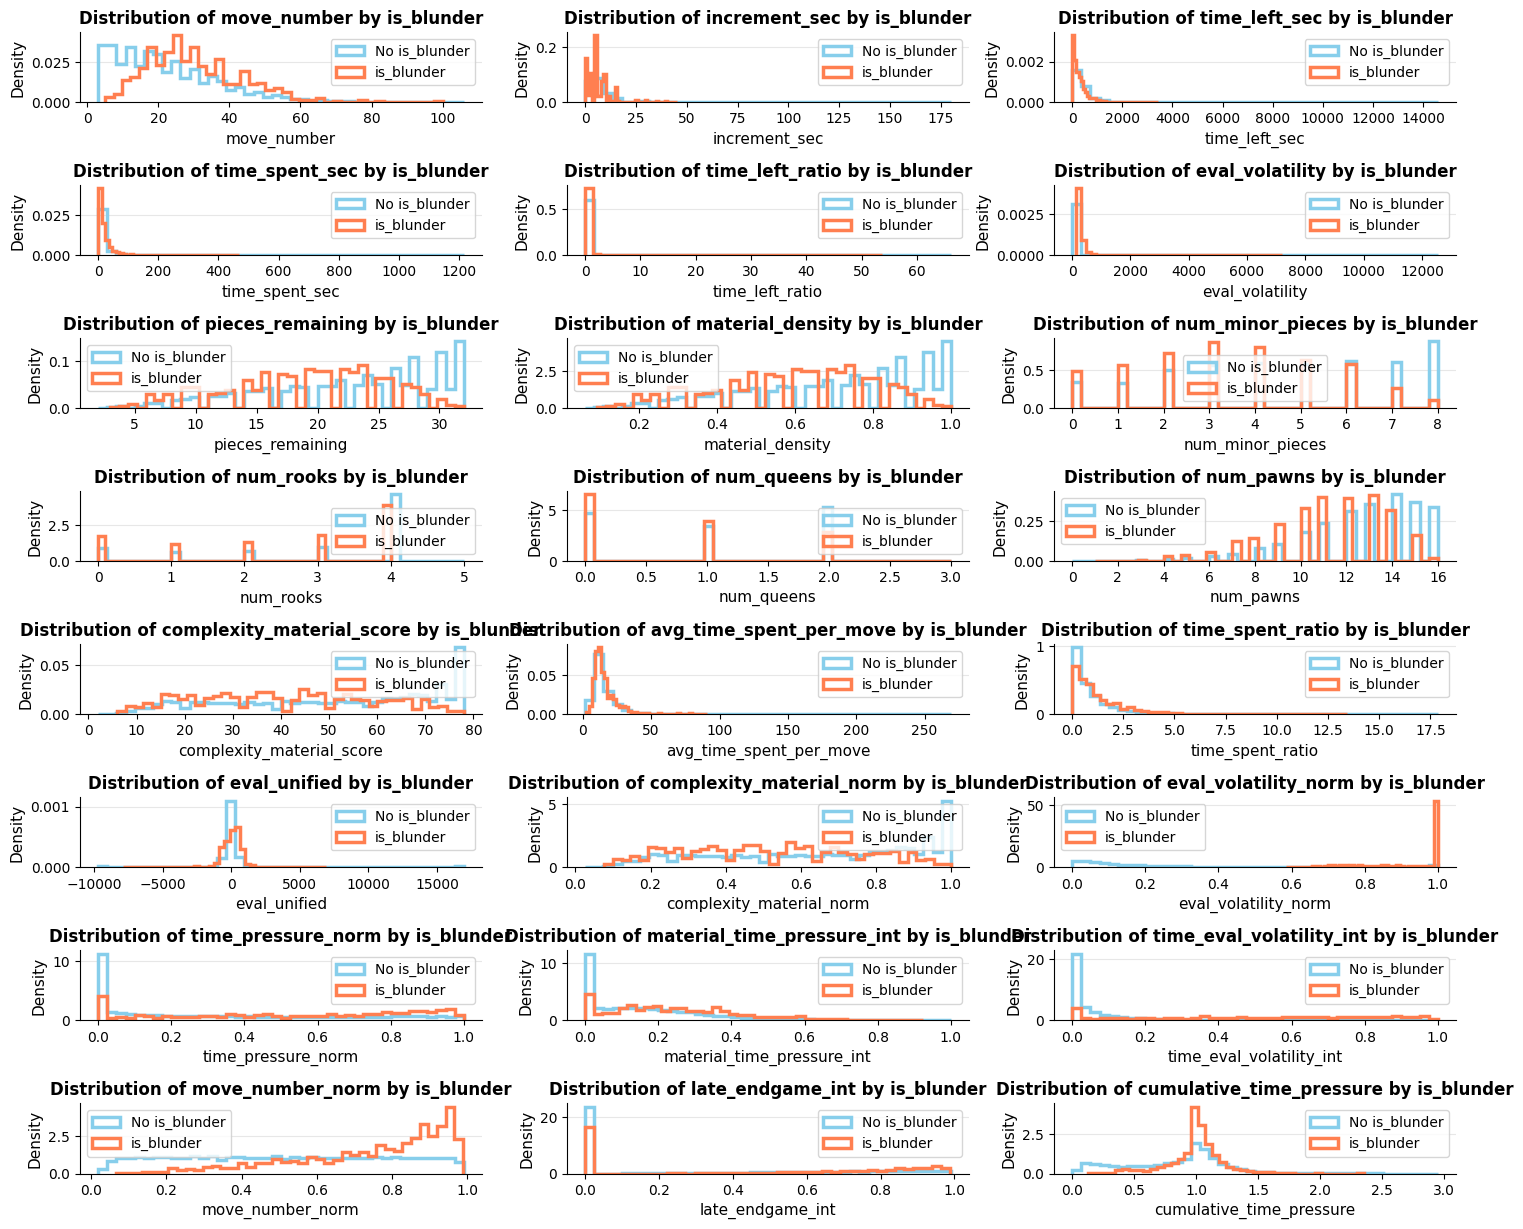

In [28]:
plot_numeric_features_histogram(df, numeric_columns, target='is_blunder', bins=40)

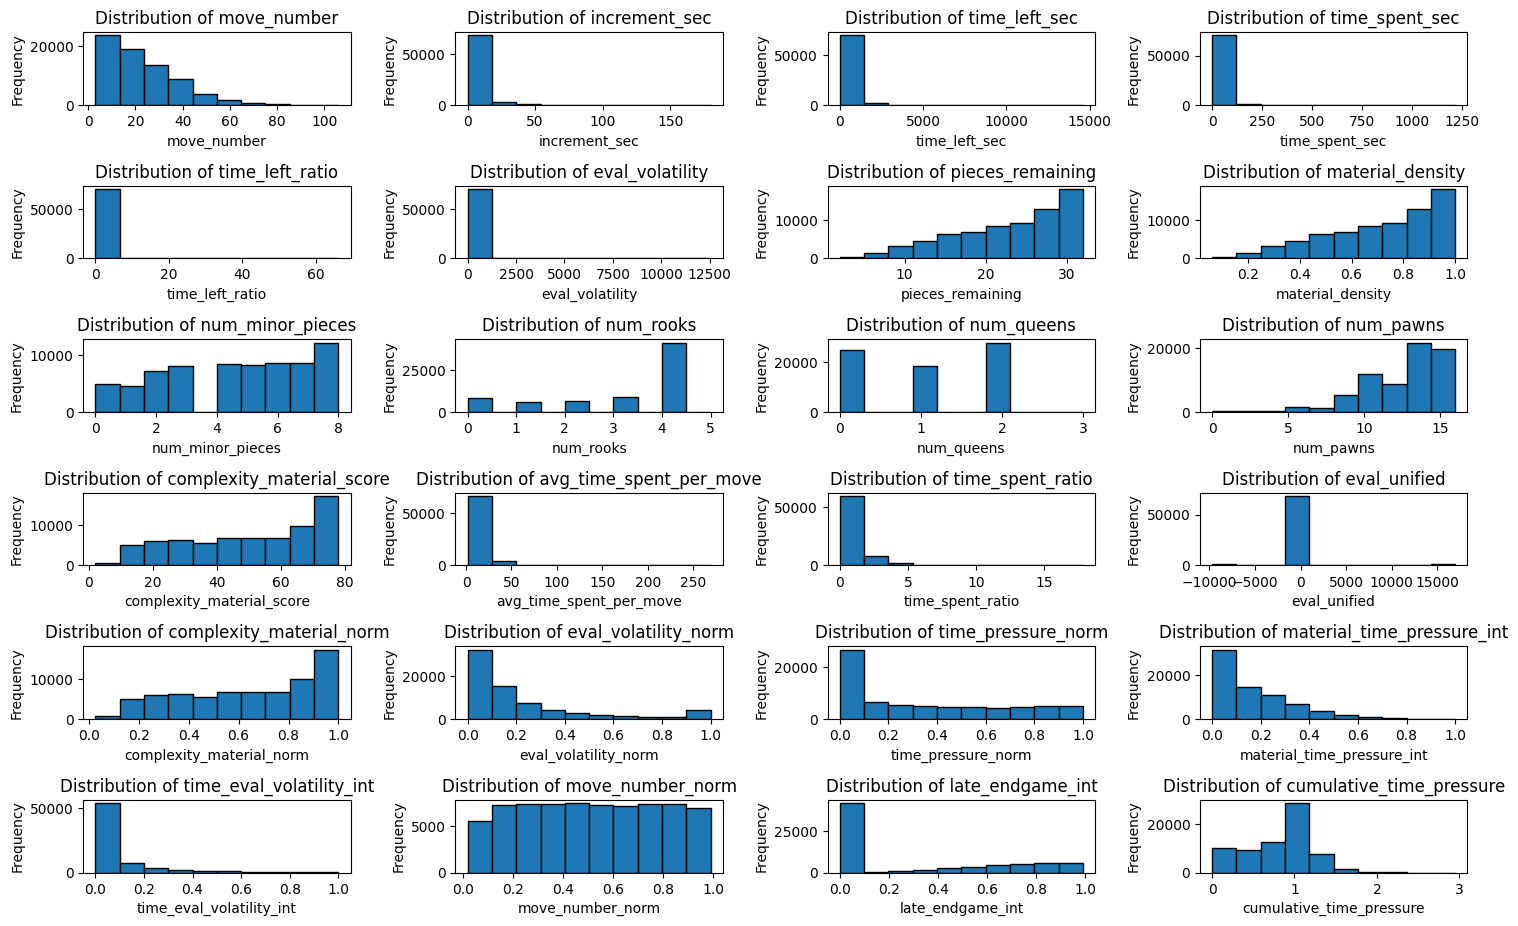

In [29]:
num_cols = len(numeric_columns)
n_cols = 4
n_rows = 8

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].hist(df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide empty subplots if there are any
for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
is_inaccuracy_percentages = df.groupby('is_inaccuracy')[numeric_columns].mean()
is_inaccuracy_percentages

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,avg_time_spent_per_move,time_spent_ratio,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure
is_inaccuracy,,,,,,,,,,,,,,,,,,,,,,,,
0,22.287875,6.877379,430.600792,15.673117,0.790463,152.818841,22.698983,0.709343,4.627153,2.962016,1.045065,12.622213,50.719337,15.551733,0.999157,110.004847,0.650248,0.211084,0.336499,0.162629,0.092489,0.511463,0.292914,0.817588
1,24.065909,7.414394,421.931890,25.662273,0.732625,85.322324,22.154167,0.692318,4.380303,2.968939,0.975379,12.285606,49.049621,16.291719,1.518942,27.827273,0.628841,0.377571,0.413820,0.221860,0.162017,0.584617,0.295965,0.942693


In [31]:
is_blunder = df.groupby('is_blunder')[numeric_columns].mean()
is_blunder

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,avg_time_spent_per_move,time_spent_ratio,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure
is_blunder,,,,,,,,,,,,,,,,,,,,,,,,
0,22.237613,6.903321,432.248732,15.942059,0.790841,146.892983,22.732766,0.710399,4.635403,2.968998,1.046987,12.631261,50.805346,15.573054,1.013551,107.744633,0.651351,0.207109,0.336482,0.163607,0.089203,0.510863,0.290422,0.819707
1,30.343781,6.480901,294.794104,22.996709,0.614904,386.039707,18.965720,0.592679,3.421156,2.499510,0.732615,11.129285,40.483839,15.998125,1.352738,53.039177,0.519024,0.915066,0.537614,0.248495,0.498383,0.741906,0.472312,0.995208


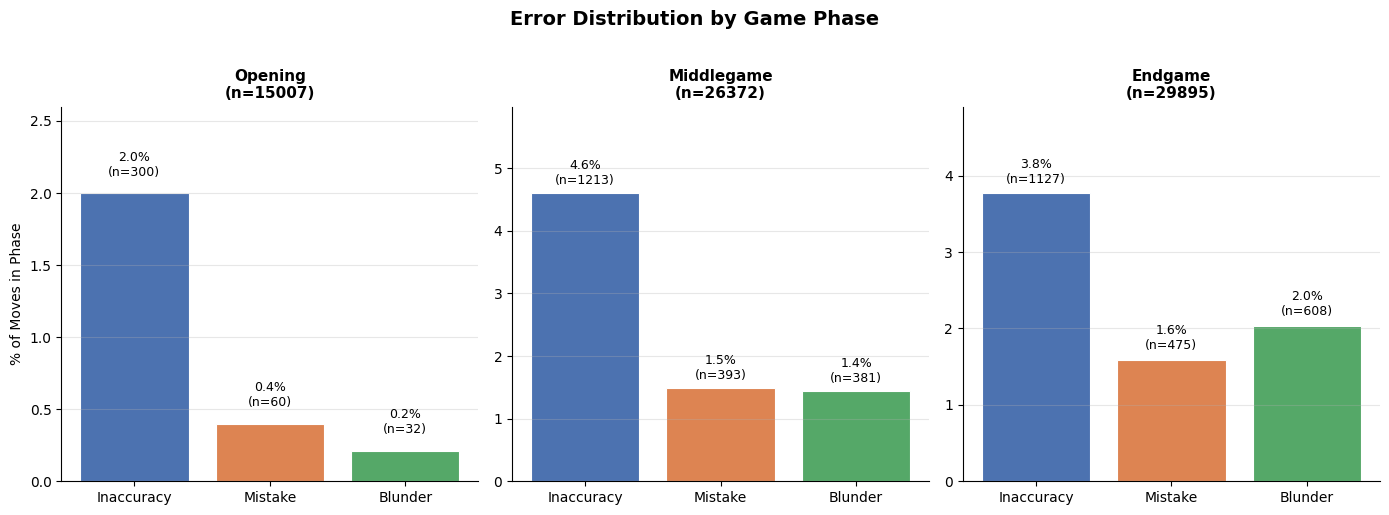

In [32]:
# Plot Error Distribution by Game Phase

error_types = ['is_inaccuracy', 'is_mistake', 'is_blunder']
error_labels = ['Inaccuracy', 'Mistake', 'Blunder']
phases = ['is_opening', 'is_middlegame', 'is_endgame']
phase_labels = ['Opening', 'Middlegame', 'Endgame']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle('Error Distribution by Game Phase', fontsize=14, fontweight='bold', y=1.02)

for ax, phase_col, phase_label in zip(axes, phases, phase_labels):
    phase_df = df[df[phase_col] == 1]
    total = len(phase_df)

    counts = [phase_df[e].sum() for e in error_types]
    pcts   = [100 * c / total for c in counts]

    bars = ax.bar(error_labels, pcts, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{phase_label}\n(n={total})', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Moves in Phase' if ax == axes[0] else '')
    ax.set_ylim(0, max(pcts) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars with count and percentage
    for bar, count, pct in zip(bars, counts, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{pct:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

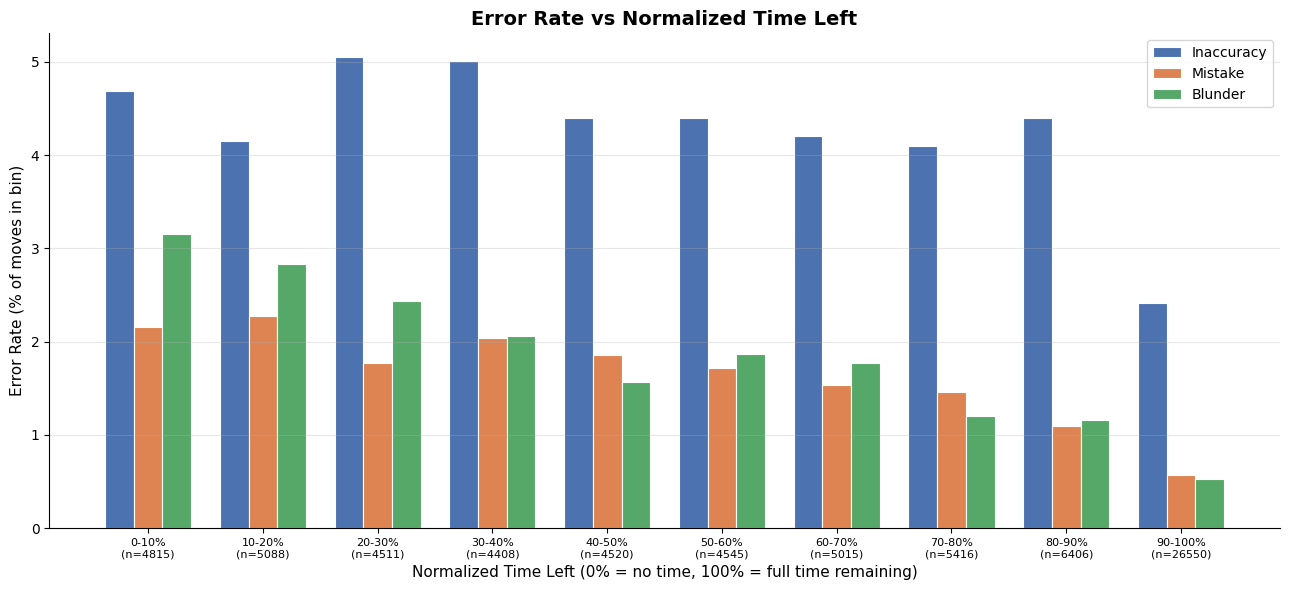

In [33]:
# Plot Error Rate vs Normalized Time Left
df_clean = df

# Clip at 1.0 — any time_left > initial_time (due to large increments) maps to 100%
df_clean['time_left_ratio_clipped'] = df_clean['time_left_ratio'].clip(0, 1)

df_clean['time_left_bin'] = pd.cut(
    df_clean['time_left_ratio_clipped'],
    bins=10,
    labels=[f'{int(i*10)}-{int((i+1)*10)}%' for i in range(10)]
)

# Calculate error rate per bin
grouped    = df_clean.groupby('time_left_bin', observed=True)[error_types].mean() * 100
bin_counts = df_clean.groupby('time_left_bin', observed=True).size()

fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(grouped))
width = 0.25

for i, (error_col, label, color) in enumerate(zip(error_types, error_labels, colors)):
    ax.bar(x + i * width, grouped[error_col], width,
           label=label, color=color, edgecolor='white', linewidth=0.8)

xtick_labels = [f'{b}\n(n={bin_counts[b]})' for b in grouped.index]
ax.set_xticks(x + width)
ax.set_xticklabels(xtick_labels, fontsize=8)

ax.set_xlabel('Normalized Time Left (0% = no time, 100% = full time remaining)', fontsize=11)
ax.set_ylabel('Error Rate (% of moves in bin)', fontsize=11)
ax.set_title('Error Rate vs Normalized Time Left', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# Use this for both modeling and descriptive analytics
df['time_left_ratio_clipped'] = df['time_left_ratio'].clip(0, 1)

# Recalculate time_pressure_norm from the clipped version
df['time_pressure_norm'] = (1 - df['time_left_ratio_clipped']).clip(0, 1)

In [35]:
df.to_csv('data/clownmitmuetze_with_features_engineered_for_model.csv', index = False)